In [280]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import shutil
from sensor_fusion import kalman_filters, height

In [281]:
import configparser

# Initialize the parser
config = configparser.ConfigParser()

# Read the config file
config.read('config.ini')

ACCELERATION_SMOOTHING = config['processing'].getfloat('acceleration_smoothing')
BAROMETER_SMOOTHING = config['processing'].getfloat('barometer_smoothing')
LOWER_ACC_THRESHOLD = config['processing'].getfloat('lower_acc_threshold')
UPPER_ACC_THRESHOLD = config['processing'].getfloat('upper_acc_threshold')
C_LIM = config['processing'].getint('c_lim')

In [282]:
def load_data(path):
    """
    Loads the the data into a dataframe
    @params
    path: where the data to analyse is
    """
    df = pd.read_csv(path)

    if df['timestamp'].iloc[0] > 0:
        df['timestamp'] = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000
    
    df['raw_acceleration'] = df['acceleration']
    
    return df

We will only work with the df['acc'] column as this will allow us to change it to just acc_z in the future if need be

In [283]:
def save_df(df, path, number):
    """
    Saves the dataframe
    @params
    df: dataframe
    path: the path to save the df to
    name: 
    """
    os.makedirs(path, exist_ok=True)
    df.to_csv(f"{path}/{number}.csv", index=False)

In [284]:
def drift_correction(df, col, bound):
    """
    Removes the offset on the acceleration
    @params
    df: dataframe
    bound: how much the function will accept a lack of significant movement
    """
    rolling_sum = 0
    num_of_pnts = 0
    for acc in df[col]:
        if acc == df[col].iloc[0] or abs(rolling_sum / num_of_pnts - acc) < bound:
            rolling_sum += acc
            num_of_pnts += 1
    df[col] -= rolling_sum / num_of_pnts


In [285]:
def smooth(df, col, SMOOTHING):
    """
    Smooths data values (also add small lag)
    @params
    df: dataframe
    col: column name to smooth
    
    """

    smoothed_values = []
    prev = None
    for row in df[col]:

        if prev is None:
            smoothed_value = row
        else:
            smoothed_value = (prev + SMOOTHING * row) / (1 + SMOOTHING)
        
        prev = smoothed_value
        smoothed_values.append(smoothed_value)

    df[col] = smoothed_values


In [286]:
def correct_vel_at_stationary(df, col, effect):
    """
    When stage == 0, reduce velocity to 0 by effect
    @params
    df: dataframe
    col: column name
    effect: how much to reduce at each timestep
    """
    assert "rStages" in df.columns, "rStages needs to be in the dataframe"
    assert col in df.columns, f"{col} needs to be in the dataframe"
    for i in range(len(df)):

        if df['rStages'].iloc[i] == 0:
            if df[col].iloc[i] > effect:
                df.loc[i:, [col]] = df.loc[i:, [col]] - effect
            elif df[col].iloc[i] < - effect:
                df.loc[i:, [col]] = df.loc[i:, [col]] + effect
            else:
                df.at[i, col] = 0
                    

In [287]:
def differentiate(df, u, v, new_name):
    """
    Differentiation of u by v
    @params:
    u, v: du/dv
    new_name: resulting column name
    """
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        du = df[u].iloc[i] - df[u].iloc[i - 1]
        dv = df[v].iloc[i] - df[v].iloc[i - 1]

        if dv != 0:
            df.at[i, new_name] = du / dv

In [288]:
def integrate(df, u, v, new_name):
    """
    Integration of u by v
    @params:
    df: dataframe
    u, v: ∫ u dv
    new_name: resulting columns name
    """
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        avg_u = (df[u].iloc[i] + df[u].iloc[i - 1]) / 2
        dv = df[v].iloc[i] - df[v].iloc[i - 1]
        
        df.at[i, new_name] = df[new_name].iloc[i - 1] + avg_u * dv

In [289]:

# Now only works for single/many journeys - not partial journeys
def add_stages(df, LB, UB, col, prefix):
    """
    Attaches stages to the dataframe based off of values on lable col,
    stages change at threshold values based off of LB & UB
    @params:
    df: datframe
    LB: Lower Bound (0-1)
    UB: Upper Bound (0-1)
    col: label to base stages off of
    prefix: unique for result label on df
    
    """
    max_acc = max(df[col])
    min_acc = min(df[col])
    new_col = prefix + "Stages"

    pos_a_lt = LB * max_acc
    pos_a_ut = UB * max_acc

    neg_a_lt = LB * min_acc
    neg_a_ut = UB * min_acc

    df[new_col] = 0
    C = 0
    Clim = 10
    up = False
    down = False
    i = 0
    while i < len(df):
        acc = df[col].iloc[i]
        curr_stage = df[new_col].iloc[i]

        if curr_stage in [0, 2] and (acc > pos_a_ut or acc < neg_a_ut):
            C += 1
            up = True
        elif curr_stage in [1, 3] and (acc < pos_a_lt and acc > neg_a_lt):
            C += 1
            down = True
        else:
            C = 0
            up = False
            down = False
        
        if C >= Clim and (up or down):
            j = i
            while (
                (up and (df[col].iloc[j] > pos_a_lt or df[col].iloc[j] < neg_a_lt))
                or (down and (df[col].iloc[j] < pos_a_lt and df[col].iloc[j] > neg_a_lt))
            ):
                j -= 1
                
            df.loc[j:, [new_col]] = (df[new_col].iloc[i] + 1) % 4
            i = j # May remove later
        
        i += 1
            


In [290]:
def linear_offset(df, label, offset, start, stop):
    """
    time-dependent correction or transformation of the label values,
    with the offset controlling how much change happens across the time range
    @params
    df: dataframe
    label: column name to edit
    offset: 
    start: 
    stop: 
    """
    dt = df['timestamp'].iloc[stop] - df['timestamp'].iloc[start]
    for i in range(start, stop):
        df.at[i, label] = df[label].iloc[i] - offset * ((df['timestamp'].iloc[i] - df['timestamp'].iloc[start]) / dt)

In [291]:
def get_dist(df, col, start, end):
    """
    Gets mean and variance of sample of col in df from start to end
    @params
    df: dataframe
    col: column name
    start: beginning of calculation
    end: end of calculation
    """
    mean = df.loc[start:end, col].mean()
    var_sum = 0
    for i in range(start, end):
        var_sum += (df[col].iloc[i] - mean) ** 2
    return mean, var_sum / (end - start - 1)

In [292]:
def single_correct_height_and_get_floors(df, height_label):
    assert 'aStages' in df.columns, "aStages needs to be in the dataframe"
    assert height_label in df.columns, f"{height_label} needs to be in the dataframe"
    floors = [0]

    i = 0
    while i < len(df):
        height_data = []
        while i < len(df) and (not len(height_data) or df['aStages'].iloc[i] == 0):
            if df['aStages'].iloc[i] == 0:
                height_data.append(df[height_label].iloc[i])
            i += 1

        if (len(height_data) <= 4): continue

        np_floors = np.array(floors)
        height_data = np.array(height_data)
        height_data = height_data[int(len(height_data) * 0.25):int(len(height_data) * 0.75)]
        height = np.mean(height_data)
        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif < 1.2:
            abs_min_index = np.argmin(np.abs(floor_height_differences) - abs_min_floor_height_dif)
            df.loc[i - len(height_data):, [height_label]] = df.loc[i - len(height_data):, [height_label]] + floor_height_differences[abs_min_index]
        else:
            floors.append(float(height))
        
    return floors
        

In [293]:
def proporionate_correct_and_get_floors(df, height1_label, height2_label):
    assert 'aStages' in df.columns, "aStages needs to be in the dataframe"
    assert height1_label in df.columns, f"{height1_label} needs to be in the dataframe"
    assert height2_label in df.columns, f"{height2_label} needs to be in the dataframe"
    floors = [0]

    i = 0
    while i < len(df):
        height1_data = []
        height2_data = []
        while i < len(df) and (not len(height1_data) or df['aStages'].iloc[i] == 0):
            if df['aStages'].iloc[i] == 0:
                height1_data.append(df[height1_label].iloc[i])
                height2_data.append(df[height2_label].iloc[i])
            i += 1

        if (len(height1_data) <= 4 or len(height2_data) <= 4): continue

        height1_data = height1_data[int(len(height1_data) * 0.25):int(len(height1_data) * 0.75)]
        height2_data = height2_data[int(len(height2_data) * 0.25):int(len(height2_data) * 0.75)]

        np_floors = np.array(floors)

        # Determine whether or not it is a new floor
        height_data = (np.array(height1_data) * 0.8 + np.array(height2_data) * 0.2) # True height estimate
        height = np.mean(height_data)

        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif > 1.2:

            floors.append(float(height))
            
            np_floors = np.array(floors)
            floor_height_differences = np_floors - height
            abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        floor_index = np.argmin(np.abs(floor_height_differences - height))
        # Move height1 to match with true height
        floor_height1_differences = np_floors - np.mean(height1_data)
        offset1 = floor_height1_differences[floor_index]
        df.loc[i - len(height1_data):, [height1_label]] = df.loc[i - len(height1_data):, [height1_label]] + offset1

        #Move height2 to match with true height
        floor_height2_differences = np_floors - np.mean(height2_data)
        offset2 = floor_height2_differences[floor_index]
        df.loc[i - len(height2_data):, [height2_label]] = df.loc[i - len(height2_data):, [height2_label]] + offset2
        
    return floors

In [294]:
def dependant_correction_and_get_floors(df, height1_label, height2_label):

    """
    
    """

    assert 'aStages' in df.columns, "aStages needs to be in the dataframe"
    assert height1_label in df.columns, f"{height1_label} needs to be in the dataframe"
    assert height2_label in df.columns, f"{height2_label} needs to be in the dataframe"
    floors = [0]
    dependant_floors = [0]

    i = 0
    previous_stationary_point = 0
    while i < len(df):
        height1_data = []
        height2_data = []
        while i < len(df) and (not len(height1_data) or df['aStages'].iloc[i] == 0):
            if df['aStages'].iloc[i] == 0:
                height1_data.append(df[height1_label].iloc[i])
                height2_data.append(df[height2_label].iloc[i])
            i += 1

        if (len(height1_data) <= 4 or len(height2_data) <= 4): continue

        height1_data = height1_data[int(len(height1_data) * 0.25):int(len(height1_data) * 0.75)]
        height2_data = height2_data[int(len(height2_data) * 0.25):int(len(height2_data) * 0.75)]

        np_floors = np.array(floors)
        height = np.mean(height1_data)

        floor_height_differences = np_floors - height
        abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))

        if abs_min_floor_height_dif > 1.2:

            floors.append(float(height))
            dependant_floors.append(float(np.mean(height2_data)))
            
            np_floors = np.array(floors)
            floor_height_differences = np_floors - height
            abs_min_floor_height_dif = np.min(np.abs(floor_height_differences))
        
        floor_index = np.argmin(np.abs(floor_height_differences - height))
        start_stationary_index = i - 2 * len(height1_data)
        # Move height1 to match with floor height
        floor_height1_differences = np_floors - np.mean(height1_data)
        offset1 = floor_height1_differences[floor_index]
        df.loc[start_stationary_index:, [height1_label]] = df.loc[start_stationary_index:, [height1_label]] + offset1
        linear_offset(df, height1_label, - offset1, previous_stationary_point, start_stationary_index)

        #Move height2 to match with floor height
        floor_height2_differences = np.array(dependant_floors) - np.mean(height2_data)
        offset2 = floor_height2_differences[floor_index]
        df.loc[start_stationary_index:, [height2_label]] = df.loc[start_stationary_index:, [height2_label]] + offset2
        linear_offset(df, height2_label, - offset2, previous_stationary_point, start_stationary_index)

        previous_stationary_point = i

    return (floors, dependant_floors)
        


In [295]:
def get_floors(df, col):

    """
    Gets the stationary values in col at stage 0,
    then groups the ones which are close to one another
    """

    potential_floors = []
    floor_indexes = []
    round_1dp = lambda x: int(x * 10) / 10
    
    i = 0
    while i < len(df):

        if df['aStages'].iloc[i] == 0:

            standing_height = []
            while i < len(df) and df['aStages'].iloc[i] == 0:
                standing_height.append(df[col].iloc[i])
                i += 1

            standing_height = np.array(standing_height)

            start = int(len(standing_height) * 0.25)
            end = int(len(standing_height) * 0.75)

            potential_floors.append(
                round_1dp(standing_height[start:end].mean())
            )
            floor_indexes.append((start, end))

        i += 1

    floor_clusters = []
    floor_var = 1 # floor height of 2m
    for i in range(len(potential_floors)):
        floor = potential_floors[i]

        for cluster in floor_clusters:

            if abs(np.mean(cluster) - floor) < floor_var:
                cluster.append(floor)
                break
        else:
            floor_clusters.append([floor])
    
    return [np.mean(cluster) for cluster in floor_clusters]
    


In [ ]:
def get_intervals(df):
    maximas = []
    i = 15
    min_interval = 120
    while i < len(df):
        interval_max = df['true_velocity'][i:min(len(df), i + min_interval)].abs().idxmax()
        if interval_max != i:
            i += interval_max - i
        elif abs(df['true_velocity'].iloc[i]) > 0.175:
            maximas.append(df['timestamp'].iloc[i])
            i += min_interval
        else:
            i += 1

    intervals = [
        (0, (maximas[0] + maximas[1]) / 2)  # First interval
    ] + [
        ((maximas[i - 1] + maximas[i]) / 2, (maximas[i] + maximas[i + 1]) / 2)
        for i in range(1, len(maximas) - 1)
    ] + [
        ((maximas[-2] + maximas[-1]) / 2, df['timestamp'].iloc[-1])  # Final interval
    ]

    return intervals

    

In [296]:
def get_true_values(df, accelerometer_variance, barometer_variance):

    """
    Integrates the kalman filter to predict better values by combining the sensors
    @params
    df: dataframe with data
    accelerometer_variance: The variance of the accelerometer
    barometer_variance: The variance of the barometer
    """
    
    df['true_height'] = None
    df['true_velocity'] = None
    kf = kalman_filters.KalmanFilter(0, 0, accelerometer_variance, barometer_variance)
    for i in df.index:

        if not i:
            dt = df['timestamp'].iloc[0] / 1000
        else:
            dt = (df['timestamp'].iloc[i] - df['timestamp'].iloc[i - 1]) / 1000

        kf.predict_with_accelerometer(df['raw_acceleration'].iloc[i], dt)

        # kf.update_with_model(df['model_height'], df['model_velocity'])
        kf.update_with_barometer(df['barometer_height'].iloc[i])

        height, velocity = kf.get_estimate()
        df.loc[i, 'true_height'] = height
        df.loc[i, 'true_velocity'] = velocity
    

In [297]:
def smooth_kalman(df, col, variance):
    kf = kalman_filters.SingleValueKalmanFilter(0, variance)
    smoothed = []
    for i in df.index:
        v = df[col].iloc[i]

        if not i:
            dt = df['timestamp'].iloc[0] / 1000
        else:
            dt = (df['timestamp'].iloc[i] - df['timestamp'].iloc[i - 1]) / 1000

        smoothed.append(kf.update(v, dt))
    
    df[col] = smoothed

In [298]:


# save_dir = "./analysed/"

# for item in os.listdir(save_dir):
#     item_path = os.path.join(save_dir, item)
#     if os.path.isfile(item_path) or os.path.islink(item_path):
#         os.remove(item_path)
#     elif os.path.isdir(item_path):
#         shutil.rmtree(item_path)

# datastreams = "./datastreams"
# folders = os.listdir(datastreams)
# dtype = [('timestamp', 'int32'), ('acceleration', 'float32'), ('pressure', 'float32')]
# FREQUENCY = 10
# data_size_from_mins = lambda mins : int(FREQUENCY * 60 * mins)
# data_shape = (data_size_from_mins(10),)
# increment = 5

# for folder in folders:
#     path = f"{datastreams}/{folder}"
#     curr_data = []
#     journey = 0
#     data_file = 0
#     while data_file < len(os.listdir(path)):
#         data_path = f"{path}/{data_file}.dat"
#         prev_data_file = data_file
#         data = np.memmap(data_path, dtype=dtype, mode='r', shape=data_shape)
#         start = 0
#         end = increment

#         while end <= data_shape[0]:
#             if data_file != prev_data_file:
#                 prev_data_file = data_file
#                 data_path = f"{path}/{data_file}.dat"
#                 data = np.memmap(data_file, dtype=dtype, mode='r', shape=data_shape)

#             curr_data.extend(data[start:end])
#             df = pd.DataFrame(np.array(curr_data, dtype=dtype), columns=['timestamp', 'acceleration'])
#             df['raw_acceleration'] = df['acceleration']
#             df['timestamp'] -= df['timestamp'].iloc[0]

#             # var_a = (acc_smooth * var_raw_acc) / (2 + acc_smooth)
#             smooth(df, 'acceleration', ACCELERATION_SMOOTHING)
#             drift_correction(df, bound=0.02)

#             add_stages(df, LOWER_ACC_THRESHOLD, UPPER_ACC_THRESHOLD, 'acceleration', 'a')

#             first_one_index = df[df['aStages'] == 1].index.min()
#             if df['aStages'].iloc[-1] != 1 or not pd.notna(first_one_index):
#                 end += increment
#                 start += increment
#                 continue

#             df_slice = df.iloc[first_one_index + 1:]
#             zeros_after = df_slice[df_slice['aStages'] == 0]
#             if not zeros_after.empty:
#                 zero_after_one_index = zeros_after.index.min()

#             if zeros_after.empty or not pd.notna(zero_after_one_index):
#                 end += increment
#                 start += increment
#                 continue
            
#             print("Journey found!")
#             # Found the journey
#             half_stationary = (len(df) - zero_after_one_index) // 2

#             df = df[:-half_stationary]
#             if half_stationary > end:
#                 data_file -= 1
            
#             end = (end - half_stationary) % data_shape[0]
#             start = (start - half_stationary) % data_shape[0]

#             curr_data.clear()
#             start = end
#             end += min(increment, data_shape[0] - end)

#             mean, acc_var = get_dist(df, 'raw_acceleration', 0, df[df['aStages'] == 1].index[0])

#             differentiate(df, 'acceleration', 'timestamp', 'jerk')

#             #velocity variance = Sum 0...n: ((dt ** 2) / 2) * acc_var
#             integrate(df, 'acceleration', 'timestamp', 'model_velocity')

#             # Velocity variance resets to 0 at each stationary location
#             correct_vel_at_stationary(df, 'model_velocity', 0.0005)

#             # Height variance = Sum 0...n: ((dt ** 2) / 2) * velocity variance
#             integrate(df, 'model_velocity', 'timestamp', 'model_height')
            
#             # get_true_values(df, acc_var, 0)
                
#             save_df(df, save_dir + folder, journey)
#             journey += 1
        
#         data_file += 1


In [299]:
save_dir = "./analysed/"

for item in os.listdir(save_dir):
    item_path = os.path.join(save_dir, item)
    if os.path.isfile(item_path) or os.path.islink(item_path):
        os.remove(item_path)
    elif os.path.isdir(item_path):
        shutil.rmtree(item_path)

datastreams = "./datastreams"
folder = os.listdir(datastreams)[0]
dtype = [('timestamp', 'int32'), ('acceleration', 'float32'), ('pressure', 'float32')]
FREQUENCY = 10
data_size_from_mins = lambda mins : int(FREQUENCY * 60 * mins)
data_shape = (data_size_from_mins(10),)

data_path = f"{datastreams}/{os.listdir(datastreams)[0]}/0.dat"
data = np.memmap(data_path, dtype=dtype, mode='r', shape=data_shape)

df = pd.DataFrame(data, columns=['timestamp', 'acceleration', 'pressure'])
df['raw_acceleration'] = df['acceleration']

drift_correction(df, 'raw_acceleration', bound=0.02)

df = df[df['timestamp'] != 0]
df.reset_index(drop=True, inplace=True)
df['timestamp'] -= df['timestamp'].iloc[0]

smooth_kalman(df, 'raw_acceleration', 0.05)
add_stages(df, LOWER_ACC_THRESHOLD, UPPER_ACC_THRESHOLD, 'raw_acceleration', 'r')

_, acc_var = get_dist(df, 'raw_acceleration', 0, df[df['rStages'] == 1].index[0])

integrate(df, 'raw_acceleration', 'timestamp', 'raw_velocity')
correct_vel_at_stationary(df, 'raw_velocity', 0.005)

integrate(df, 'raw_velocity', 'timestamp', 'raw_height')

df['barometer_height'] = df['pressure'].apply(height.calculate_height)
bar_mean, bar_var = get_dist(df, 'barometer_height', 0, df[df['rStages'] == 1].index[0])
# df['barometer_height'] -= bar_mean
drift_correction(df, 'barometer_height', bound=0.5)

get_true_values(df, acc_var, bar_var)

# differentiate(df, 'true')
    
save_df(df, save_dir + folder, "bob")


In [300]:
def chart(col1, col2=None):
    fig, ax1 = plt.subplots()

    labels = {
        'acceleration': 'Acceleration (m/s^2)',
        'jerk': 'Jerk (m/s^3)',
        'model_height': 'Height (m)',
        'model_velocity': 'Velocity (m/s)',
        'avStages': "vel stages",
        'aStages': "acc stages",
        'rStages': "acc stages",
        'true_height': "True Height (m)",
        'barometer_height': "Barometer Height (m)",
        'raw_acceleration': "Raw Acceleration (m/s^2)",
        'raw_velocity': "Raw Velocity (m/s)",
        'raw_height': "Raw Height (m)",
        'true_velocity': "True Velocity (m/s)"
    }
    col1_label = labels[col1]

    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(col1_label, color='tab:blue')

    if 'Stages' in col1: col = df[col1] / 4
    else: col = df[col1]

    ax1.plot(df['timestamp'], col, color='tab:blue', label=col1)
    ax1.tick_params(axis='y', labelcolor='tab:blue')   
    plt.axhline(y=0, color='r', linestyle='--', label='y=0')

    if col2 != None:
        ax2 = ax1.twinx()
        ax2.set_ylabel(col2, color='tab:red')

        if 'Stages' in col2: col = df[col2] / 4
        else: col = df[col2]

        ax2.plot(df['timestamp'], df[col2], color='tab:red', label=col2)
        ax2.tick_params(axis='y', labelcolor='tab:red')

        minimum = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
        maximum = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
        ax1.set_ylim(minimum, maximum)
        ax2.set_ylim(minimum, maximum)

        plt.title(f'{col1_label} and {col2} vs. Time')
    
    else:
        plt.title(f'{col1_label} vs. Time') 

    fig.tight_layout()

    plt.show()

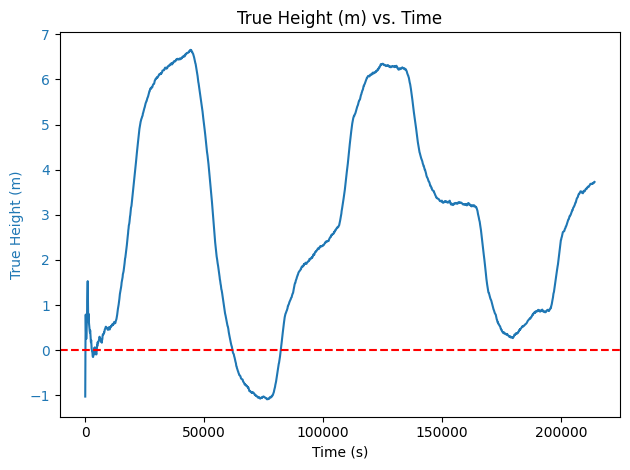

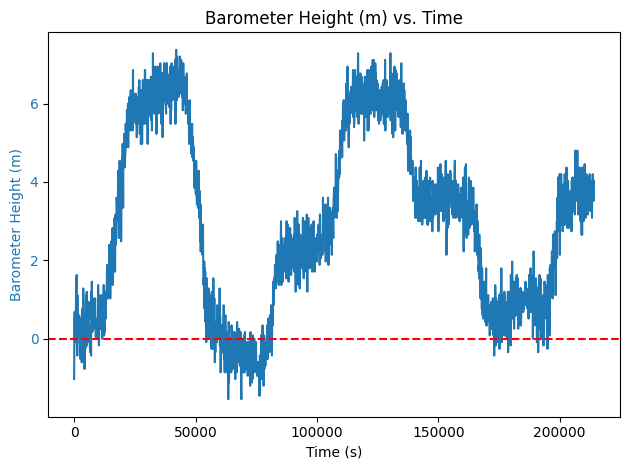

In [301]:
chart('true_height')
chart('barometer_height')


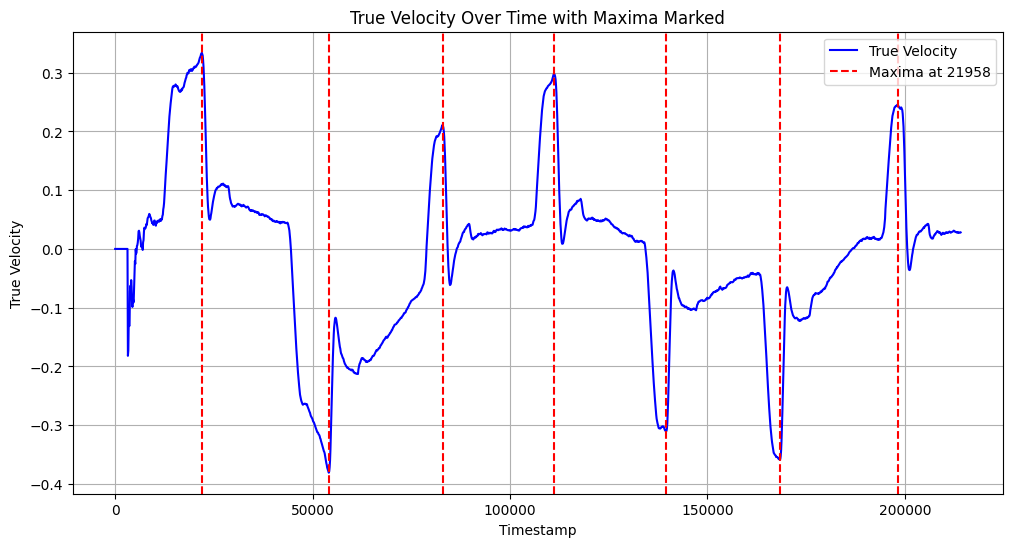

In [ ]:
for i in range(29):
    df.loc[i, 'true_velocity'] = 0
# chart('true_velocity')

    
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['true_velocity'], label='True Velocity', color='blue')

# Add vertical lines at the maxima
for ts in maximas:
    plt.axvline(x=ts, color='red', linestyle='--', label=f'Maxima at {ts}' if ts == maximas[0] else "")

# Add labels and title
plt.xlabel('Timestamp')
plt.ylabel('True Velocity')
plt.title('True Velocity Over Time with Maxima Marked')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


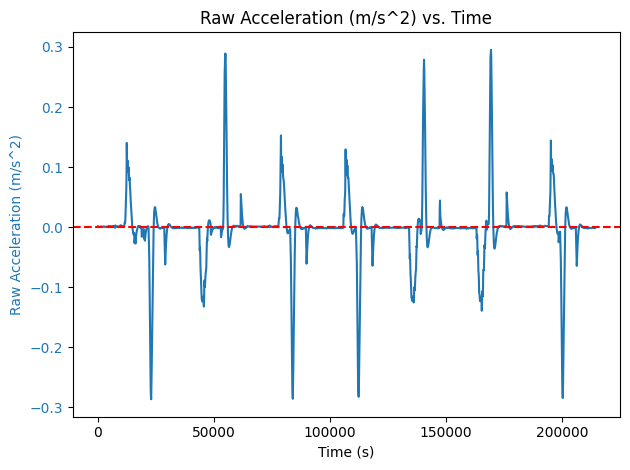

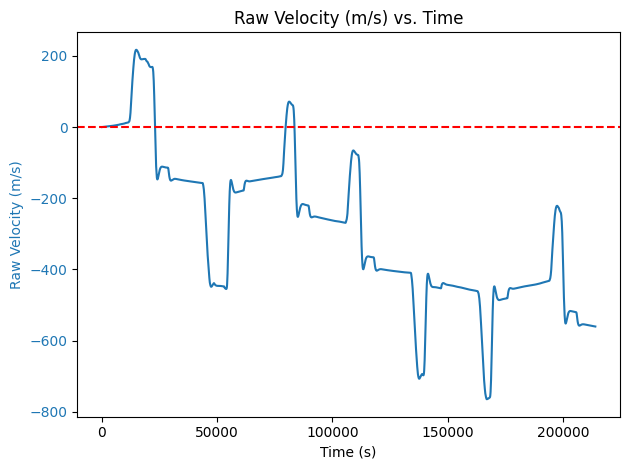

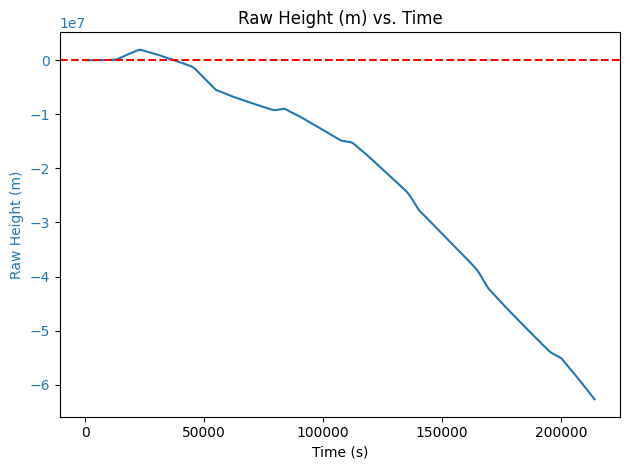

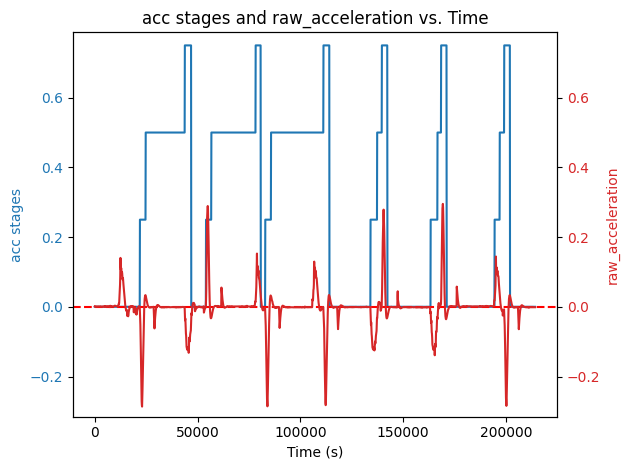

In [303]:
chart('raw_acceleration')
chart('raw_velocity')

# chart('acceleration')
chart('raw_height')
chart('rStages', 'raw_acceleration')
# chart('model_velocity')
# chart('jerk')
